In [9]:
import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

local_path = "data/raw/mearec_test_10s.h5"
recording, sorting_true = se.read_mearec(local_path)
fs = recording.get_sampling_frequency()

filtered_trace = np.load("data/raw/filtered_trace.npy")
detected_spike_times = np.load("data/raw/detected_spike_times.npy")

Extracted 187 waveforms, each 128 samples long


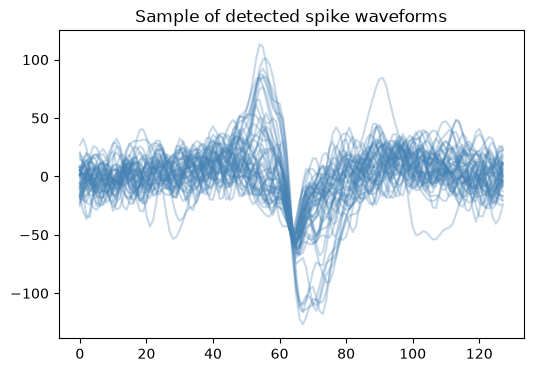

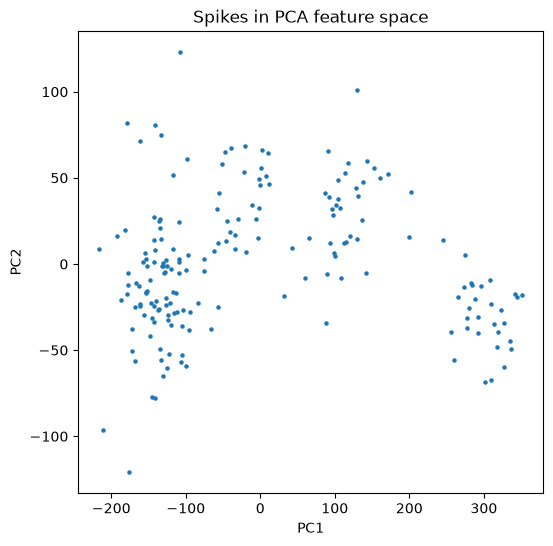

In [10]:
def extract_waveforms(signal, spike_times, fs, window_ms=2.0):
    window_samples = int((window_ms / 1000) * fs)
    waveforms = []
    valid_times = []
    for t in spike_times:
        if t - window_samples >= 0 and t + window_samples < len(signal):
            waveforms.append(signal[t - window_samples : t + window_samples])
            valid_times.append(t)
    return np.array(waveforms), np.array(valid_times)

waveforms, valid_spike_times = extract_waveforms(filtered_trace, detected_spike_times, fs)
print(f"Extracted {len(waveforms)} waveforms, each {waveforms.shape[1]} samples long")

plt.figure(figsize=(6, 4))
for w in waveforms[:50]:
    plt.plot(w, alpha=0.3, color='steelblue')
plt.title("Sample of detected spike waveforms")
plt.show()

pca = PCA(n_components=2)
features = pca.fit_transform(waveforms)

plt.figure(figsize=(6, 6))
plt.scatter(features[:, 0], features[:, 1], s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spikes in PCA feature space")
plt.show()

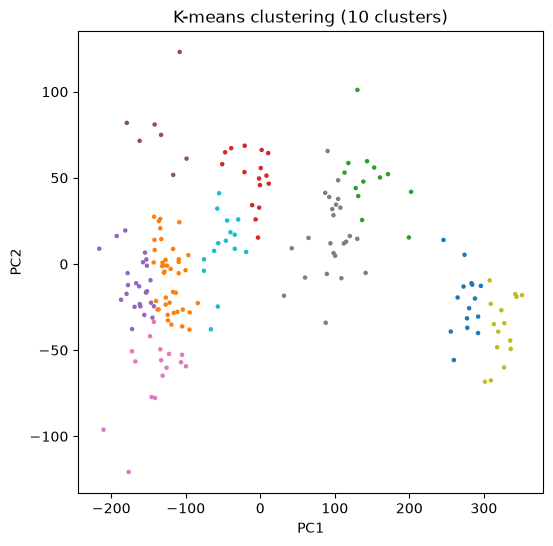

In [11]:
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features)

plt.figure(figsize=(6, 6))
plt.scatter(features[:, 0], features[:, 1], c=cluster_labels, cmap='tab10', s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-means clustering ({n_clusters} clusters)")
plt.show()

In [12]:
np.save("data/raw/valid_spike_times.npy", valid_spike_times)
np.save("data/raw/cluster_labels.npy", cluster_labels)
print("saved")

saved
